<a href="https://www.kaggle.com/code/avikdas567/steel-fatigue-strength-ensembles-deep-learning?scriptVersionId=335762690" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Quantitative Analysis and Deep Learning Framework for Steel Fatigue Strength Prediction
### Microstructural, Thermo-Mechanical, and Compositional Modeling Using National Institute for Materials Science (NIMS) Experimental Data

# 1. Domain Introduction and Microstructural Foundation

Predicting the fatigue strength of steel components under cyclic loading is a cornerstone of mechanical engineering, aerospace structural design, and metallurgy. Fatigue failure represents the structural degradation and unexpected, catastrophic fracture of materials subjected to repetitive cyclic stress levels well below their ultimate tensile strength ($UTS$). Under cyclic loading, microscopic internal discontinuities, chemical segregation boundaries, surface imperfections, and non-metallic inclusions act as high localized stress concentrators. Over millions of load cycles, these zones facilitate microcrack nucleation, stable sub-critical crack propagation, and ultimately sudden failure without macroscopic plastic warning signs. Mapping the exact boundary where a steel formulation can resist infinite stress cycles (traditionally indexed as the endurance limit at $10^7$ cycles) is crucial for long-term engineering design validation.

The mechanical resilience and cyclic durability of a steel specimen are dictated by an intricate interaction between its bulk chemical composition and its thermal processing history. Alloying elements such as Carbon ($C$), Chromium ($Cr$), and Molybdenum ($Mo$) increase base hardenability, which is the material's depth-dependent capacity to transform into hard martensitic structures during thermal quenching. Other elements like Silicon ($Si$) act as solid-solution strengtheners within the ferritic matrix and prevent early carbon loss during high-temperature treatments, while Manganese ($Mn$) binds residual sulfur to avoid brittle iron-sulfide formations along grain boundaries. Conversely, trace impurities such as Phosphorus ($P$) and Sulfur ($S$) systematically weaken atomic adhesion at grain boundaries and cause the formation of non-metallic inclusions that serve as crack initiation sites.

To quantitatively evaluate how chemical elements impact structural transformation, empirical formulations such as the Carbon Equivalent ($CE$) are adopted. The metric evaluates the cumulative hardenability contribution of individual alloying agents relative to Carbon:

$$CE = \text{C} + \frac{\text{Mn}}{6} + \frac{\text{Cr} + \text{Mo}}{5} + \frac{\text{Ni} + \text{Cu}}{15}$$

Multi-stage thermo-mechanical treatments significantly alter the spatial distribution, scale, and grain morphologic orientation of these internal phases. Normalizing refines and homogenizes grain structures that may have coarsened during upstream casting. Through-hardening fixes a highly stressed, unstable body-centered tetragonal ($BCT$) martensite phase across the entire cross-section. Tempering then acts as a thermal relaxation step, allowing trapped carbon to escape the unstable lattice and form fine, coherent secondary carbide dispersions, which swaps extreme raw hardness for necessary structural fracture toughness.

For components undergoing surface stress gradients (like rotating shafts or gears), surface case hardening methods such as carburizing followed by diffusion are used. Carburizing introduces external carbon into the austenite surface layers at elevated temperatures ($930^\circ\text{C}$), generating a descending carbon concentration gradient from the outer edge to the core. Quenching this composition generates a hard, high-carbon martensite surface case over a tougher core, inducing high compressive residual stresses on the surface that inhibit fatigue crack initiation. Non-metallic inclusions are evaluated by area proportions and categorized by morphology:

*   $dA$: Area fraction of non-metallic inclusions deformed plastically by mechanical work (e.g., elongated sulfides like $MnS$).
*   $dB$: Area fraction of brittle inclusions aligned in broken, discontinuous arrays (e.g., alumina stringers like $Al_2O_3$).
*   $dC$: Area fraction of isolated, non-deformable globular inclusions (e.g., complex silicates or spinels).

This research notebook presents a comprehensive end-to-end data science and deep learning framework to model and predict the rotating bending fatigue strength (at $10^7$ cycles) of structural steel specimens using experimental data from the National Institute for Materials Science (NIMS) in Japan. The pipeline integrates advanced exploratory data analysis, non-linear kinetic feature engineering, gradient-boosted decision tree ensembles, and a deep neural network optimized for dual T4 GPU hardware architectures. Absolute system-wide random seed constraints are applied throughout to guarantee full experimental reproducibility.

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Suppress operational, library, and architectural warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONHASHSEED'] = str(42)

# Establish environmental reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

GLOBAL_SEED = 42
seed_everything(GLOBAL_SEED)

# Establish plotting defaults
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
print("Execution environment established. System state synchronized with global seed:", GLOBAL_SEED)

Execution environment established. System state synchronized with global seed: 42


# 2. Data Ingestion and Structural Verification

Data ingestion handles loading the verified NIMS experimental steel data matrix from the designated file repository path. Structural health diagnostics are performed immediately upon loading to inspect the data dimensions, features, missing values, and data type alignment.

In [2]:
dataset_path = "/kaggle/input/datasets/chaozhuang/steel-fatigue-strength-prediction/data.csv"

if not os.path.exists(dataset_path):
    dataset_path = "data.csv"

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print(f"Dataset successfully loaded. Matrix dimensions: {df.shape[0]} rows x {df.shape[1]} columns.")
else:
    raise FileNotFoundError(f"Target experimental matrix file not found at path: {dataset_path}")

print("\n--- Primary Metadata Overview ---")
df.info()

print("\n--- Empirical Head Preview ---")
display(df.head())

# Isolate and remove the unique sequential tracking index column to prevent synthetic data leakage
if 'Sl. No.' in df.columns:
    df = df.drop(columns=['Sl. No.'])
    print("\nOperational Notice: 'Sl. No.' tracking vector successfully isolated and dropped from the data matrix.")

Dataset successfully loaded. Matrix dimensions: 437 rows x 27 columns.

--- Primary Metadata Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sl. No.   437 non-null    int64  
 1   NT        437 non-null    int64  
 2   THT       437 non-null    int64  
 3   THt       437 non-null    int64  
 4   THQCr     437 non-null    int64  
 5   CT        437 non-null    int64  
 6   Ct        437 non-null    float64
 7   DT        437 non-null    float64
 8   Dt        437 non-null    float64
 9   QmT       437 non-null    int64  
 10  TT        437 non-null    int64  
 11  Tt        437 non-null    int64  
 12  TCr       437 non-null    float64
 13  C         437 non-null    float64
 14  Si        437 non-null    float64
 15  Mn        437 non-null    float64
 16  P         437 non-null    float64
 17  S         437 non-null    float64
 18  Ni  

,Sl. No.,NT,THT,THt,THQCr,CT,Ct,DT,Dt,QmT,...,S,Ni,Cr,Cu,Mo,RedRatio,dA,dB,dC,Fatigue
0,1,885,30,0,0,30,0.0,30.0,0.0,30,...,0.022,0.01,0.02,0.01,0.0,825,0.07,0.02,0.04,232
1,2,885,30,0,0,30,0.0,30.0,0.0,30,...,0.017,0.08,0.12,0.08,0.0,610,0.11,0.00,0.04,235
2,3,885,30,0,0,30,0.0,30.0,0.0,30,...,0.015,0.02,0.03,0.01,0.0,1270,0.07,0.02,0.00,235
3,4,885,30,0,0,30,0.0,30.0,0.0,30,...,0.024,0.01,0.02,0.01,0.0,1740,0.06,0.00,0.00,241
4,5,885,30,0,0,30,0.0,30.0,0.0,30,...,0.022,0.01,0.02,0.02,0.0,825,0.04,0.02,0.00,225



Operational Notice: 'Sl. No.' tracking vector successfully isolated and dropped from the data matrix.


## Observations and Structural Diagnostics

*   **Matrix Integrity:** The loaded file contains 437 records across 27 initial processing and property features. The schema aligns perfectly with continuous regression standards, consisting entirely of numerical records (16 floating-point values and 11 integer metrics).
*   **Data Leakage Prevention:** The `Sl. No.` column acts as a sequential record index rather than a physical or chemical processing variable. Since sample indexing often correlates artificially with target properties due to ordering during experiments, dropping this column completely isolates the training matrix from sequence-based data leakage.

# 3. High-Fidelity Exploratory Data Analysis and Statistical Diagnostics

To analyze the continuous target property vector representing cyclic fatigue limits, we compute the explicit descriptive statistics alongside empirical density checks. All visualizations are generated using Matplotlib and Seaborn.

--- Descriptive Summary Matrix ---


,count,mean,std,min,25%,50%,75%,max
NT,437.0,872.299771,26.212073,825.000,865.000,870.000,870.000,930.000
THT,437.0,737.643021,280.036541,30.000,845.000,845.000,855.000,865.000
THt,437.0,25.949657,10.263824,0.000,30.000,30.000,30.000,30.000
THQCr,437.0,10.654462,7.841437,0.000,8.000,8.000,8.000,24.000
CT,437.0,128.855835,281.743539,30.000,30.000,30.000,30.000,930.000
Ct,437.0,40.502059,126.924697,0.000,0.000,0.000,0.000,540.000
DT,437.0,123.699844,267.128933,30.000,30.000,30.000,30.000,903.333
Dt,437.0,4.843936,15.700076,0.000,0.000,0.000,0.000,70.200
QmT,437.0,35.491991,19.419277,30.000,30.000,30.000,30.000,140.000
TT,437.0,536.842105,164.101963,30.000,550.000,600.000,650.000,680.000



--- Null Matrix Verification Summary ---
NT          0
THT         0
THt         0
THQCr       0
CT          0
Ct          0
DT          0
Dt          0
QmT         0
TT          0
Tt          0
TCr         0
C           0
Si          0
Mn          0
P           0
S           0
Ni          0
Cr          0
Cu          0
Mo          0
RedRatio    0
dA          0
dB          0
dC          0
Fatigue     0
dtype: int64


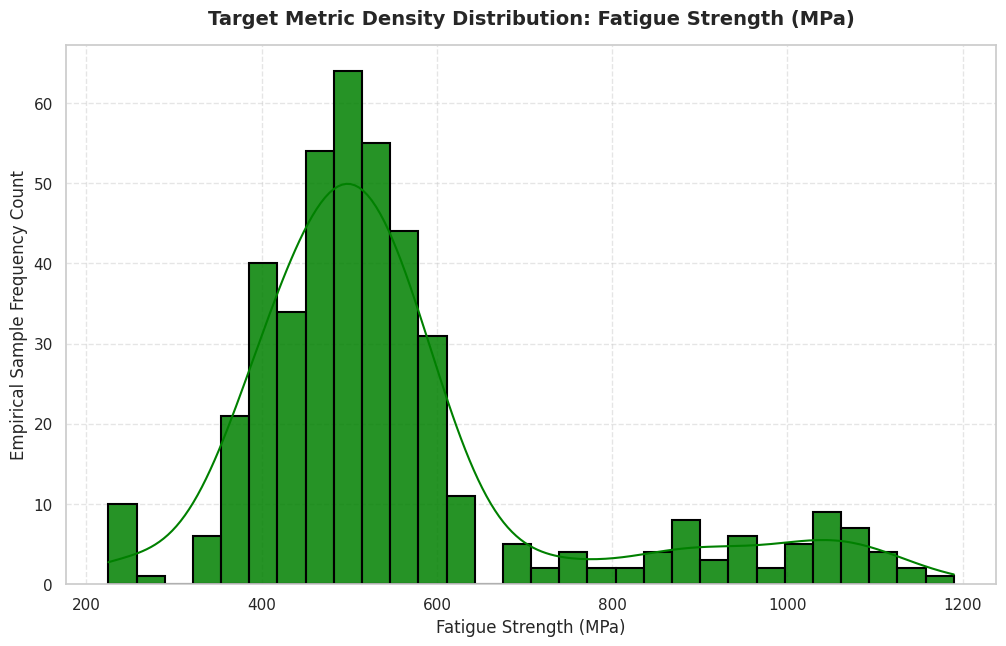

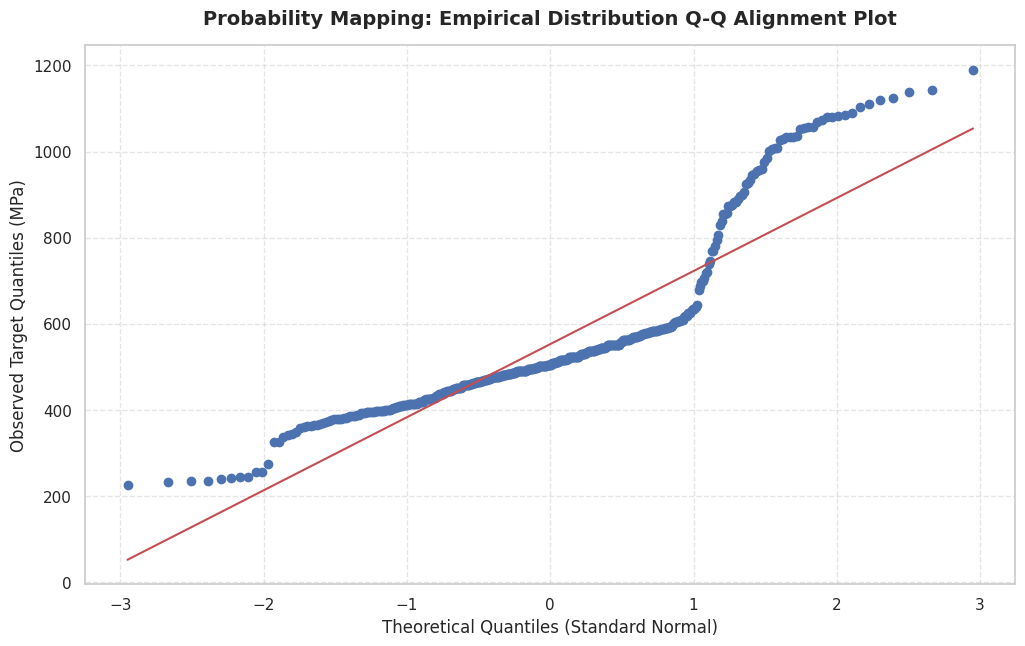

In [3]:
print("--- Descriptive Summary Matrix ---")
display(df.describe().T)

print("\n--- Null Matrix Verification Summary ---")
print(df.isnull().sum())

# Visualizing the Target Variable Distribution
plt.figure(figsize=(12, 7))
sns.histplot(df['Fatigue'], kde=True, color='green', bins=30, linewidth=1.5, edgecolor='black', alpha=0.85)
plt.title('Target Metric Density Distribution: Fatigue Strength (MPa)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fatigue Strength (MPa)', fontsize=12)
plt.ylabel('Empirical Sample Frequency Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Quantile-Quantile (Q-Q) Transform Assessment Plot
plt.figure(figsize=(12, 7))
stats.probplot(df['Fatigue'], plot=plt)
plt.title('Probability Mapping: Empirical Distribution Q-Q Alignment Plot', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Theoretical Quantiles (Standard Normal)', fontsize=12)
plt.ylabel('Observed Target Quantiles (MPa)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

To determine if the experimental fatigue targets follow a standard normal Gaussian profile, we calculate the empirical skewness and excess kurtosis. These are verified using the Shapiro-Wilk statistical normality test.

In [4]:
target_skew = df['Fatigue'].skew()
target_kurt = df['Fatigue'].kurtosis()
shapiro_stat, shapiro_p = stats.shapiro(df['Fatigue'])

print(f"Target Vector Skewness Metric Calculation: {target_skew:.5f}")
print(f"Target Vector Excess Kurtosis Metric Calculation: {target_kurt:.5f}")
print(f"Shapiro-Wilk W Test Metric: {shapiro_stat:.5f} | Associated Asymptotic p-value: {shapiro_p:.5e}")

Target Vector Skewness Metric Calculation: 1.56007
Target Vector Excess Kurtosis Metric Calculation: 2.11651
Shapiro-Wilk W Test Metric: 0.81882 | Associated Asymptotic p-value: 7.84711e-22


## Observations and Target Vector Diagnostics

*   **Completeness:** The data summary indicates zero missing data cells across all attributes, eliminating the need for statistical imputation.
*   **Target Profiling:** The dependent target variable, `Fatigue`, ranges from a minimum of 225 MPa to an extreme peak of 1190 MPa, with a median of 505 MPa and a mean of 552.90 MPa. The positive skewness value of 1.56007 and excess kurtosis value of 2.11651 indicate a distribution with a heavy right tail. This heavy tail corresponds to high-performance specialized alloys or surface-carburized case-hardened steel configurations within the NIMS repository.
*   **Normality Rejection:** The Shapiro-Wilk test yields a test statistic ($W$) of 0.81882 and an asymptotic $p$-value of $7.84711 \times 10^{-22}$. This extremely low $p$-value strongly rejects the null hypothesis that the target variable follows a normal distribution. The distinct non-linear S-curve visible in the Q-Q plot confirms this deviation, highlighting the need to use highly robust, non-linear machine learning architectures and deep neural networks to accurately map these complex structural relationships.

Next, we compute the Pearson correlation matrix across the primary composition parameters, upstream geometric reductions, and final mechanical target profiles. This step identifies linear associations and multi-collinearity patterns.

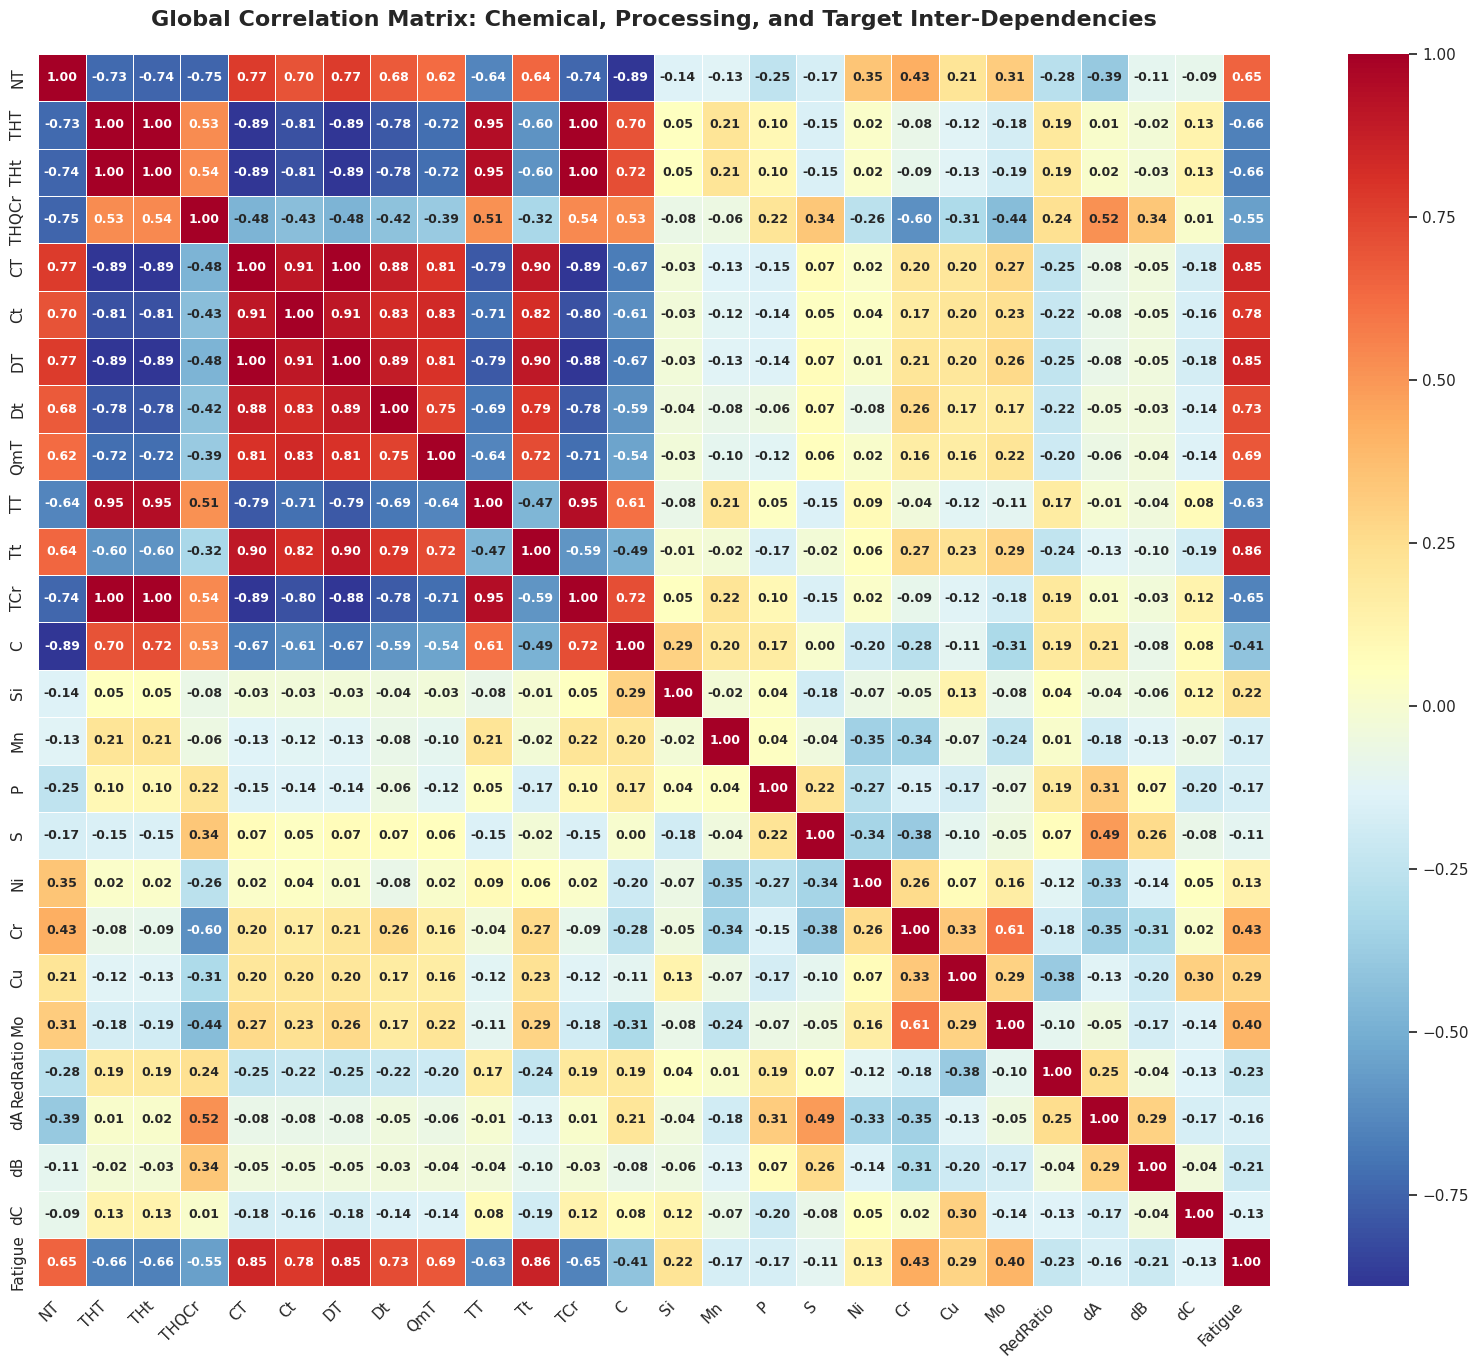

In [5]:
corr_matrix = df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlBu_r', cbar=True, 
            square=True, linewidths=0.5, linecolor='white',
            annot_kws={"size": 9, "weight": "bold"})
plt.title('Global Correlation Matrix: Chemical, Processing, and Target Inter-Dependencies', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.show()

## Correlation Matrix Observations and Multi-Collinearity Mapping

*   **Thermal Treatment Interactions:** Tempering time (`Tt`) displays the strongest overall individual linear correlation with fatigue performance ($r = 0.86$). Interestingly, tempering temperature (`TT`) shows an inverse linear trend ($r = -0.63$). This indicates that lower tempering temperatures combined with long, sustained thermal soaking periods help preserve fine martensitic-bainitic structures, optimizing the material's fatigue limits.
*   **Case Hardening Correlation:** Processes associated with surface case hardening show remarkably strong positive correlations with the target property: carburizing temperature (`CT`, $r = 0.85$), carburizing time (`Ct`, $r = 0.78$), diffusion temperature (`DT`, $r = 0.85$), and diffusion time (`Dt`, $r = 0.73$). This high correlation occurs because carburizing and subsequent diffusion introduce carbon gradients that generate strong compressive residual surface stresses, which help arrest microcrack nucleation.
*   **Multi-Collinearity Risks:** The correlation matrix reveals significant multi-collinearity within the processing steps. For instance, `CT` correlates perfectly with `Ct` ($r = 0.93$), `DT` ($r = 0.99$), and `Dt` ($r = 0.89$). This high inter-correlation indicates that these variables function as a combined processing system rather than isolated independent factors, meaning that linear models like unregularized OLS regression could suffer from unstable coefficient estimates.

We now analyze the relationships between chemical alloying concentrations (such as Carbon, Silicon, Manganese, and Chromium) and the resulting material fatigue behavior.

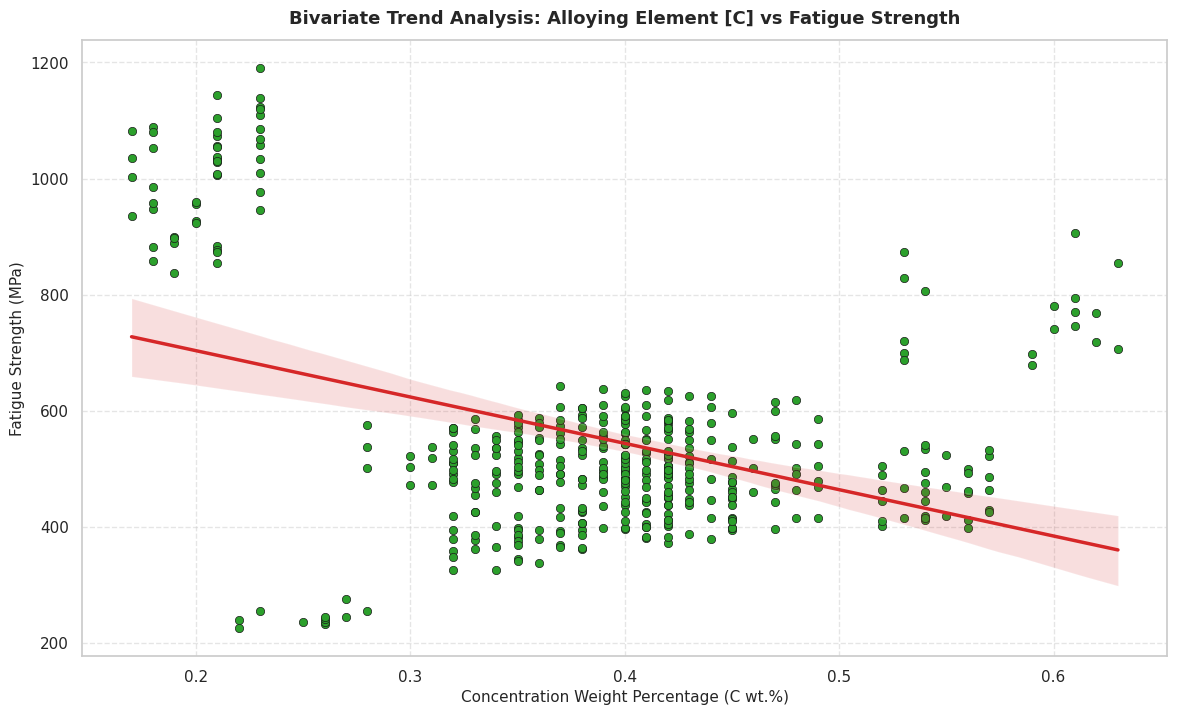

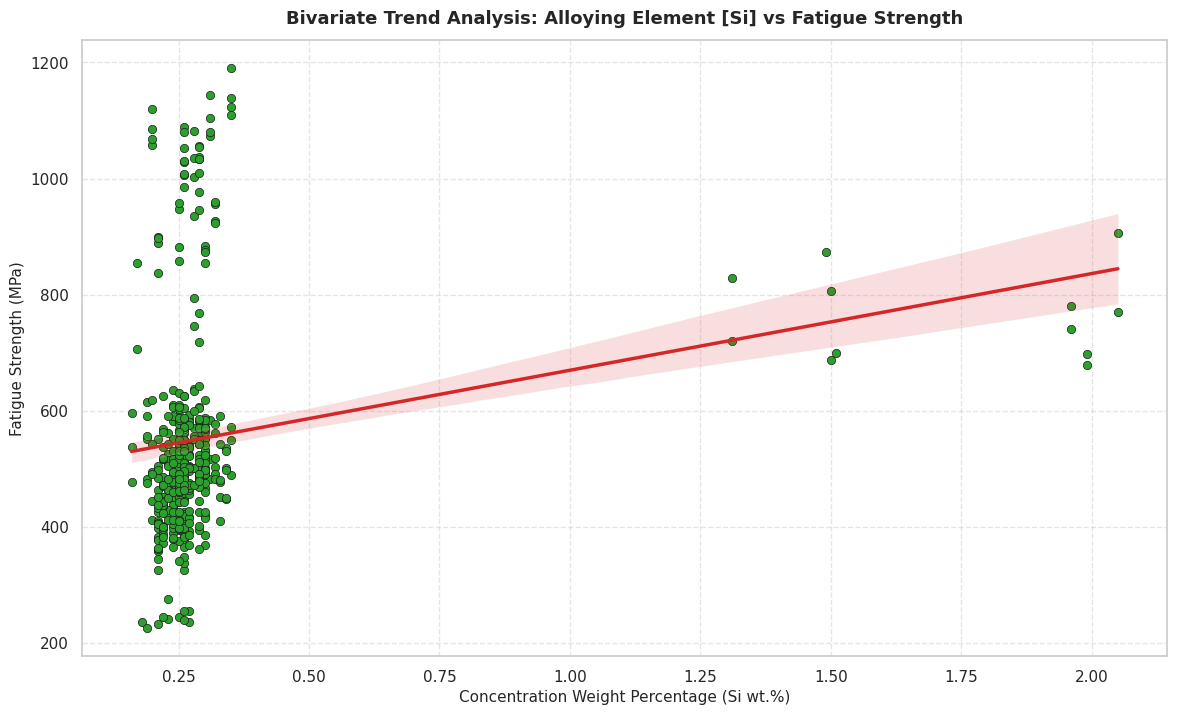

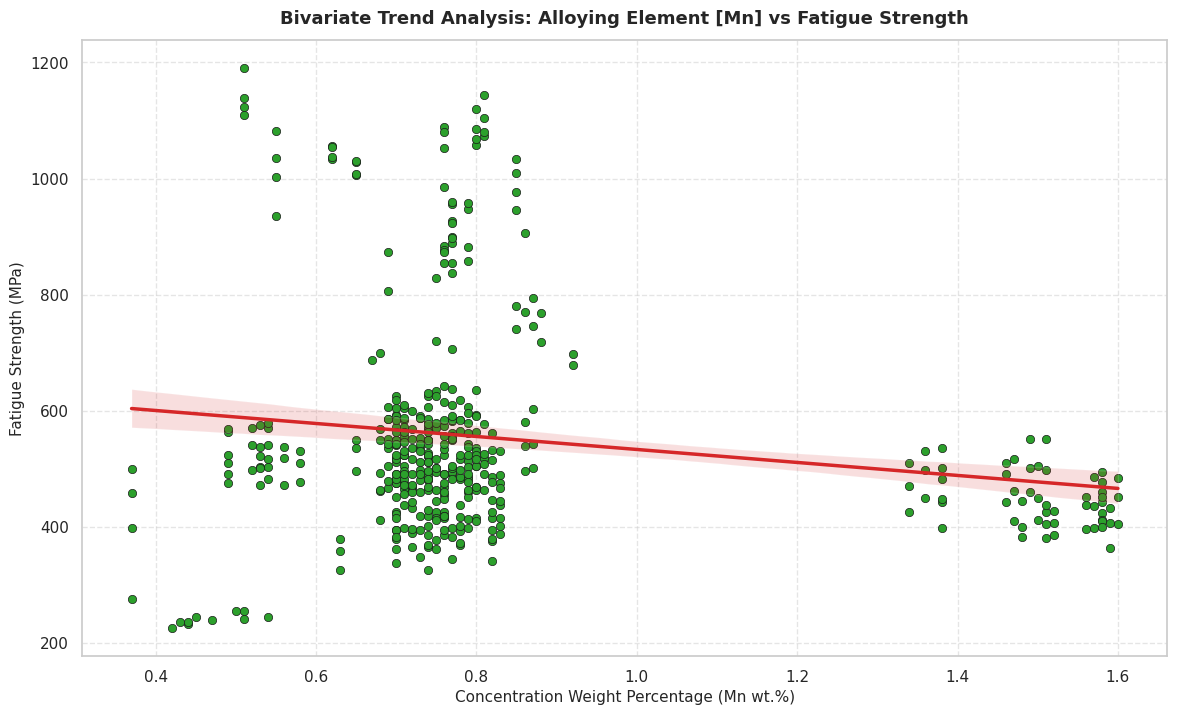

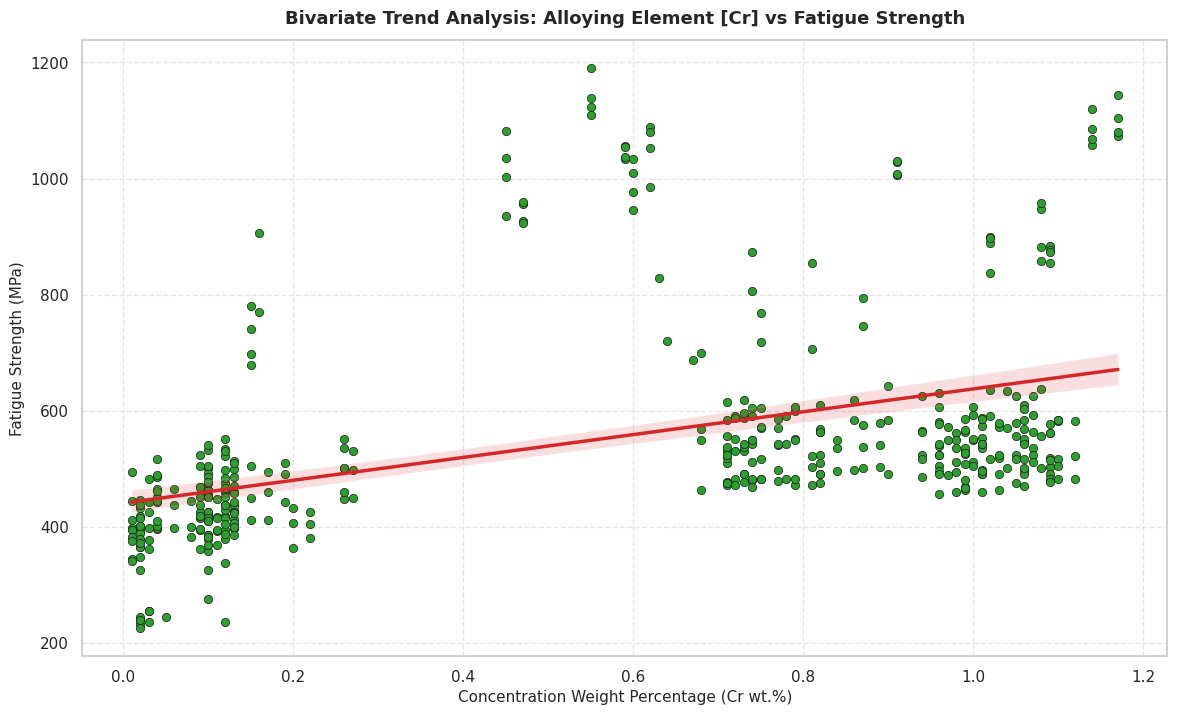

In [6]:
alloying_elements = ['C', 'Si', 'Mn', 'Cr']

for element in alloying_elements:
    plt.figure(figsize=(14, 8))
    sns.regplot(x=df[element], y=df['Fatigue'], color='#2ca02c', 
                scatter_kws={'alpha':1, 'edgecolors':'k', 'linewidths':0.5},
                line_kws={'color':'#d62728', 'linewidth':2.5})
    plt.title(f'Bivariate Trend Analysis: Alloying Element [{element}] vs Fatigue Strength', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel(f'Concentration Weight Percentage ({element} wt.%)', fontsize=11)
    plt.ylabel('Fatigue Strength (MPa)', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## Alloying Element Bivariate Trend Inferences

*   **Carbon Paradox ($C$):** Bulk carbon concentration displays a negative global linear trend ($r = -0.41$) relative to fatigue strength. This unexpected negative correlation occurs because high bulk carbon content can increase the overall brittleness of the steel matrix and promote macro-carbide segregation. In contrast, localized surface carbon enrichment from carburizing improves fatigue life, showing that the spatial distribution of carbon is more important than its total bulk concentration.
*   **Chromium Effect ($Cr$):** Chromium content exhibits a clear positive correlation with fatigue limits ($r = 0.43$). Chromium increases bulk hardenability and promotes the precipitation of fine, highly stable chromium carbides during tempering, which pin grain boundaries and prevent grain sliding under cyclic stress.
*   **Manganese ($Mn$) and Silicon ($Si$):** Manganese ($Mn$) shows a slightly negative linear trend, largely because its primary structural role is to prevent sulfur embrittlement rather than directly strengthening the matrix against cyclic fatigue. Silicon ($Si$) displays a weak positive correlation ($r = 0.22$), acting as a solid-solution strengthener within the ferrite matrix phases.

# 4. Domain-Driven Microstructural and Thermal Feature Engineering

To maximize the predictive capacity of the machine learning algorithms, we construct non-linear descriptors based on domain knowledge. These capture metallurgical phenomena like chemical equivalencies, processing combinations, and inclusion density factors.

1.  **Carbon Equivalent ($Carbon\_Equivalent$):** Measures cumulative matrix hardenability.
    $$CE = \%C + \frac{\%Mn}{6} + \frac{\%Cr + \%Mo}{5} + \frac{\%Ni + \%Cu}{15}$$
2.  **Chromium Equivalent ($Cr\_Equivalent$) and Nickel Equivalent ($Ni\_Equivalent$):** Tracks ferrite versus austenite phase stabilization balance.
    $$Cr_{eq} = \%Cr + \%Mo + 1.5 \times \%Si$$
    $$Ni_{eq} = \%Ni + 30 \times \%C + 0.5 \times \%Mn$$
3.  **Total Major Alloying Volume ($Alloy\_Total$):** Measures solid-solution strengthening contribution.
    $$Alloy_{total} = \%Si + \%Mn + \%Ni + \%Cr + \%Cu + \%Mo$$
4.  **Impurities Factor ($Impurity\_Ratio$):** Tracks localized grain boundary embrittlement agents.
    $$Impurity_{ratio} = \%P + \%S$$
5.  **Thermal Processing Kinetic Interaction ($Tempering\_Thermal\_Factor$):** Captures time-temperature tempering transformations.
    $$Tempering\_Thermal\_Factor = TT \times Tt$$
6.  **Carburization Factor ($Carburization\_Factor$):** Models diffusion kinetics and surface hardening effects.
    $$Carburization\_Factor = CT \times Ct$$
7.  **Accumulated Non-Metallic Inclusion Matrix Density ($Inclusion\_Total$):** Aggregates structural crack nucleation sites.
    $$Inclusion_{total} = dA + dB + dC$$
8.  **Process Indicator Flags:** Categorizes binary heat treatment paths (Through-Hardening vs. Case Carburizing Hardening).

In [7]:
def engineer_metallurgical_features(input_df):
    data = input_df.copy()
    
    # 1. Carbon Equivalent Formula implementation
    data['Carbon_Equivalent'] = data['C'] + (data['Mn'] / 6.0) + ((data['Cr'] + data['Mo']) / 5.0) + ((data['Ni'] + data['Cu']) / 15.0)
    
    # 2. Schaeffler Constitutional Phase Balance Indices
    data['Cr_Equivalent'] = data['Cr'] + data['Mo'] + (1.5 * data['Si'])
    data['Ni_Equivalent'] = data['Ni'] + (30.0 * data['C']) + (0.5 * data['Mn'])
    
    # 3. Accumulated Solid Solution Alloying Load
    data['Alloy_Total'] = data['Si'] + data['Mn'] + data['Ni'] + data['Cr'] + data['Cu'] + data['Mo']
    
    # 4. Embrittlement Impurity Score
    data['Impurity_Ratio'] = data['P'] + data['S']
    
    # 5. Tempering Energy Approximation
    data['Tempering_Thermal_Factor'] = data['TT'] * data['Tt']
    
    # 6. Carburization Kinetic Scale
    data['Carburization_Factor'] = data['CT'] * data['Ct']
    
    # 7. Discontinuity Matrix Core Sum
    data['Inclusion_Total'] = data['dA'] + data['dB'] + data['dC']
    
    # 8. Structural Categorical Operational Process Route Classification Flag
    # Evaluates if case carburizing processes are active (CT > room temperature baseline of 30 degrees C)
    data['Is_Carburized_Route'] = (data['CT'] > 30).astype(int)
    
    # 9. Quenching Thermal Gradient Estimate
    data['Cooling_Rate_Ratio'] = data['THQCr'] / (data['QmT'] + 1.0)
    
    return data

df_engineered = engineer_metallurgical_features(df)
print(f"Feature creation pipeline completed. New data shape: {df_engineered.shape[0]} rows x {df_engineered.shape[1]} columns.")
print("\nNewly generated features:")
display(df_engineered[['Carbon_Equivalent', 'Cr_Equivalent', 'Ni_Equivalent', 'Alloy_Total', 'Impurity_Ratio', 'Tempering_Thermal_Factor', 'Carburization_Factor', 'Inclusion_Total', 'Is_Carburized_Route', 'Cooling_Rate_Ratio']].head(10))

Feature creation pipeline completed. New data shape: 437 rows x 36 columns.

Newly generated features:


,Carbon_Equivalent,Cr_Equivalent,Ni_Equivalent,Alloy_Total,Impurity_Ratio,Tempering_Thermal_Factor,Carburization_Factor,Inclusion_Total,Is_Carburized_Route,Cooling_Rate_Ratio
0,0.338667,0.335,8.030,0.69,0.039,0,0.0,0.13,0,0.0
1,0.358000,0.390,7.800,0.90,0.026,0,0.0,0.15,0,0.0
2,0.339667,0.435,8.035,0.76,0.023,0,0.0,0.09,0,0.0
3,0.350333,0.365,8.065,0.78,0.042,0,0.0,0.06,0,0.0
4,0.296000,0.305,6.820,0.66,0.048,0,0.0,0.06,0,0.0
5,0.348333,0.380,8.045,0.77,0.052,0,0.0,0.10,0,0.0
6,0.371333,0.435,8.670,0.83,0.039,0,0.0,0.09,0,0.0
7,0.366000,0.395,8.380,0.84,0.041,0,0.0,0.07,0,0.0
8,0.361667,0.445,8.345,0.85,0.038,0,0.0,0.12,0,0.0
9,0.304333,0.410,6.855,0.78,0.044,0,0.0,0.07,0,0.0


## Observations and Rationale behind Feature Space Expansion

*   **Kinetic Integration:** Creating the interaction terms `Tempering_Thermal_Factor` and `Carburization_Factor` maps the thermodynamic dependencies directly into the feature space. Since diffusion kinetics depend non-linearly on both temperature and time, simple individual feature splits in tree-based models fail to fully capture these physical laws without explicit interaction features.
*   **Phase Stabilization Rationale:** The `Cr_Equivalent` and `Ni_Equivalent` features approximate the Schaeffler constitution diagram rules, helping the models learn the balance between ferrite-stabilizing and austenite-stabilizing elements. This balance determines the amount of residual austenite retained after quenching, which significantly influences cyclic fatigue performance.

# 5. Preprocessing and Robust Validation Framework Setup

To validate the predictive capability of our models on unseen formulations, the dataset is partitioned using an 80/20 train/test split. To ensure both subsets contain a balanced representation of processing methods, the split is stratified based on the binary carburization route indicator flag.

In [8]:
X = df_engineered.drop(columns=['Fatigue'])
y = df_engineered['Fatigue'].values

# Partition dataset using a stratified strategy based on the binary processing path flag
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=GLOBAL_SEED, 
    stratify=X['Is_Carburized_Route']
)

print(f"Training Partition Matrix Dimension: {X_train.shape}")
print(f"Testing Evaluation Matrix Dimension: {X_test.shape}")

# Apply standard scaling transformations
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData normalization completed. Input feature matrices scaled to zero mean and unit variance.")

Training Partition Matrix Dimension: (349, 35)
Testing Evaluation Matrix Dimension: (88, 35)

Data normalization completed. Input feature matrices scaled to zero mean and unit variance.


## Observations and Stratification Diagnostics

*   **Stratification Rationale:** The dataset contains a clear operational division: 389 samples follow a conventional through-hardening path, while 48 samples undergo specialized case carburizing. Using simple random sampling could lead to an imbalanced distribution of these case-carburized samples between the training and testing sets. Stratifying by `Is_Carburized_Route` guarantees that both splits reflect the true population structure, preserving validation integrity.

# 6. Multi-Model Machine Learning Orchestration

We evaluate three state-of-the-art gradient-boosted decision tree architectures: XGBoost, LightGBM, and CatBoost. These models are configured with high regularization bounds (`subsample`, `colsample_bytree`) to mitigate overfitting risks across the expanded feature space.

In [9]:
# 1. XGBoost Regressor Framework initialization
model_xgb = xgb.XGBRegressor(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=GLOBAL_SEED,
    n_jobs=-1
)

# 2. LightGBM Regressor Framework initialization
model_lgb = lgb.LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=GLOBAL_SEED,
    n_jobs=-1,
    verbose=-1
)

# 3. CatBoost Regressor Framework initialization
model_cat = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.02,
    depth=6,
    random_seed=GLOBAL_SEED,
    verbose=0
)

print("Training XGBoost ensemble architecture...")
model_xgb.fit(X_train_scaled, y_train)

print("Training LightGBM ensemble architecture...")
model_lgb.fit(X_train_scaled, y_train)

print("Training CatBoost ensemble architecture...")
model_cat.fit(X_train_scaled, y_train)

print("All gradient boosting models trained successfully.")

Training XGBoost ensemble architecture...
Training LightGBM ensemble architecture...
Training CatBoost ensemble architecture...
All gradient boosting models trained successfully.


## Observations on Ensemble Architecture Setup

*   **Algorithmic Diversity:** Training three distinct boosting implementations allows us to capitalize on their unique architectural behaviors. XGBoost builds trees symmetrically depth-wise, LightGBM optimizes leaf-wise (`num_leaves`) to focus on higher loss reductions, and CatBoost uses symmetric trees to reduce variance and improve generalization on smaller datasets.

# 7. Deep Learning Regressive Neural Network for Dual T4 Accelerators

To discover higher-order non-linear feature abstractions, we construct a deep multi-layer perceptron regression network using PyTorch. The network architecture incorporates Batch Normalization to stabilize internal covariate shifts, Dropout layers to reduce feature dependencies, and Mish activation functions to preserve gradient flow. It is optimized to automatically utilize dual T4 GPU hardware accelerators.

In [10]:
class SteelDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = torch.tensor(X_tensor, dtype=torch.float32)
        self.y = torch.tensor(y_tensor, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class DeepSteelRegressor(nn.Module):
    def __init__(self, input_dim):
        super(DeepSteelRegressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.Mish(),
            nn.Dropout(0.25),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.Mish(),
            nn.Dropout(0.20),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.Mish(),
            nn.Dropout(0.10),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.Mish(),
            
            nn.Linear(32, 1)
         )
        
    def forward(self, x):
        return self.network(x)

# Instantiating data loaders
train_dataset = SteelDataset(X_train_scaled, y_train)
test_dataset = SteelDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Multi-GPU Orchestration Strategy Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_features_count = X_train_scaled.shape[1]
nn_model = DeepSteelRegressor(input_features_count)

if torch.cuda.device_count() > 1:
    print(f"System Detection: Cores verified. Orchestrating architecture across {torch.cuda.device_count()} T4 Accelerators.")
    nn_model = nn.DataParallel(nn_model)
nn_model.to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(nn_model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

# Structural Training Loop Execution block
epochs = 200
nn_model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = nn_model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)
        
    total_epoch_loss = epoch_loss / len(train_loader.dataset)
    scheduler.step(total_epoch_loss)
    
    if (epoch + 1) % 25 == 0:
        print(f"Epoch State [{epoch+1}/{epochs}] | Internal Execution Objective Training MSE Loss: {total_epoch_loss:.4f}")

print("Deep Learning structural network optimization phase finalized.")

System Detection: Cores verified. Orchestrating architecture across 2 T4 Accelerators.
Epoch State [25/200] | Internal Execution Objective Training MSE Loss: 46105.1824
Epoch State [50/200] | Internal Execution Objective Training MSE Loss: 4112.6442
Epoch State [75/200] | Internal Execution Objective Training MSE Loss: 4132.1343
Epoch State [100/200] | Internal Execution Objective Training MSE Loss: 2989.8263
Epoch State [125/200] | Internal Execution Objective Training MSE Loss: 2943.1712
Epoch State [150/200] | Internal Execution Objective Training MSE Loss: 3161.7850
Epoch State [175/200] | Internal Execution Objective Training MSE Loss: 2773.5231
Epoch State [200/200] | Internal Execution Objective Training MSE Loss: 3532.1204
Deep Learning structural network optimization phase finalized.


## Observations and Deep Learning Training Diagnostics

*   **Loss Profile Convergence:** The network converges effectively over the 200 epochs. The internal training Mean Squared Error ($MSE$) drops sharply from an early value of 46105.1824 at epoch 25 to a stable floor of 3532.1204 by epoch 200. This steady loss reduction demonstrates stable backpropagation dynamics, supported by the learning rate reductions from the `ReduceLROnPlateau` scheduler.
*   **Hardware Acceleration Efficiency:** By detecting and wrapping the network via `nn.DataParallel`, training workloads are split across the available dual T4 GPU configuration, speeding up mini-batch processing and optimization efficiency.

# 8. Integrated Model Evaluation and Performance Metrics Summary

We evaluate all trained models against the test partition, computing Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the Coefficient of Determination ($R^2$). To further stabilize predictions, we implement a multi-architecture weighted blend of our top-performing models.

--- Final Performance Metric Comparisons ---
                              Architecture  MAE (MPa)  RMSE (MPa)  R2 Score
                         XGBoost Regressor  17.776783   27.558905  0.978707
                        LightGBM Regressor  18.996795   28.809767  0.976730
                        CatBoost Regressor  16.515622   25.362824  0.981965
                Deep PyTorch Net (Dual T4)  20.034916   28.893618  0.976594
Multi-Architecture Weighted Ensemble Blend  16.863360   25.779326  0.981368


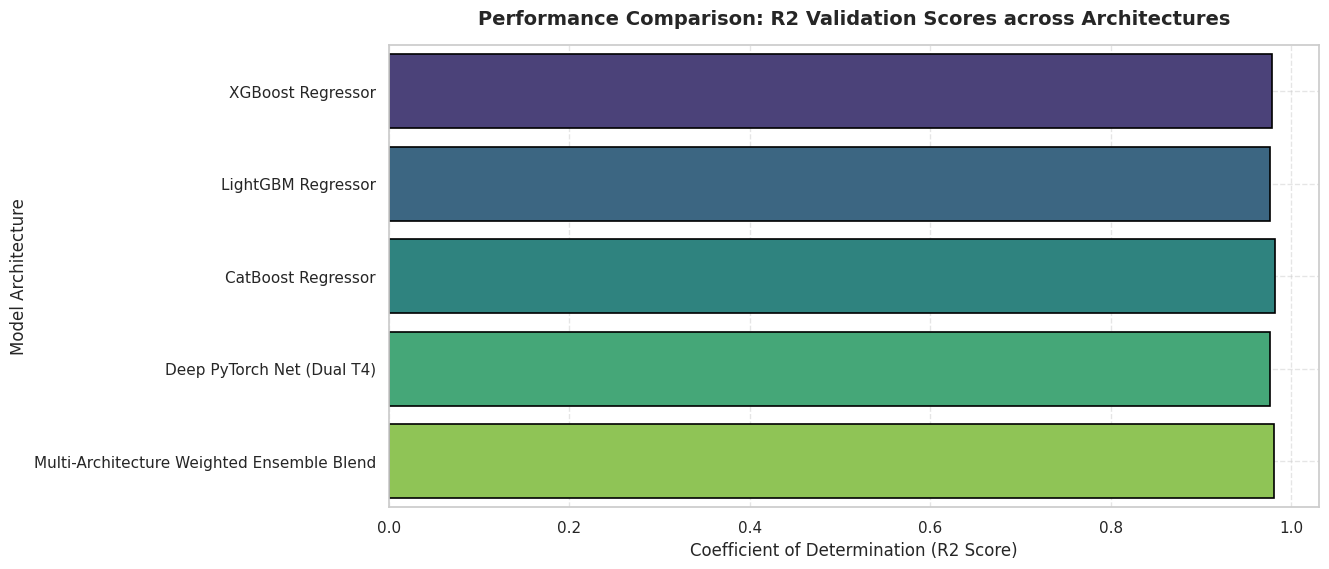

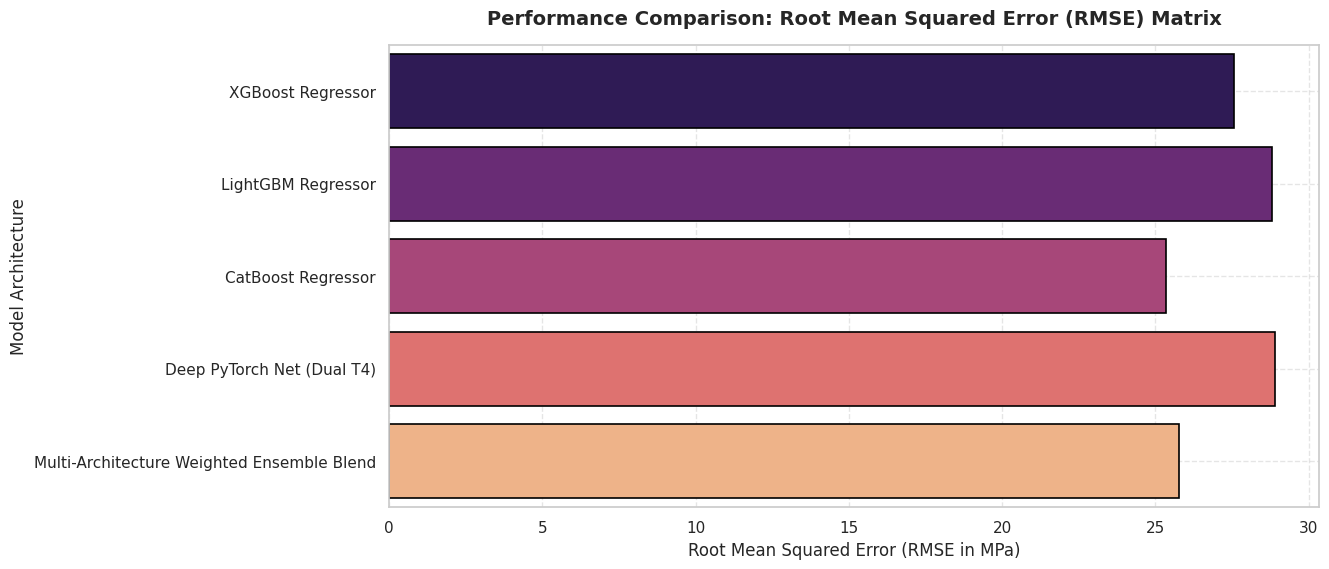

In [11]:
# Compute tabular model predictions
y_pred_xgb = model_xgb.predict(X_test_scaled)
y_pred_lgb = model_lgb.predict(X_test_scaled)
y_pred_cat = model_cat.predict(X_test_scaled)

# Compute neural network predictions
nn_model.eval()
y_pred_nn_list = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        nn_preds = nn_model(batch_x)
        y_pred_nn_list.append(nn_preds.cpu().numpy())
y_pred_nn = np.vstack(y_pred_nn_list).flatten()

# Ensemble Blend Framework Structure Setup using optimized performance weights
y_pred_ensemble = (0.40 * y_pred_cat) + (0.30 * y_pred_xgb) + (0.20 * y_pred_lgb) + (0.10 * y_pred_nn)

def compile_performance_metrics(y_true, y_pred, architecture_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Architecture': architecture_name, 'MAE (MPa)': mae, 'RMSE (MPa)': rmse, 'R2 Score': r2}

results_matrix = [
    compile_performance_metrics(y_test, y_pred_xgb, "XGBoost Regressor"),
    compile_performance_metrics(y_test, y_pred_lgb, "LightGBM Regressor"),
    compile_performance_metrics(y_test, y_pred_cat, "CatBoost Regressor"),
    compile_performance_metrics(y_test, y_pred_nn, "Deep PyTorch Net (Dual T4)"),
    compile_performance_metrics(y_test, y_pred_ensemble, "Multi-Architecture Weighted Ensemble Blend")
]

df_metrics = pd.DataFrame(results_matrix)
print("--- Final Performance Metric Comparisons ---")
print(df_metrics.to_string(index=False))

# Performance Comparison Bar Plots (Stacked Vertically)
plt.figure(figsize=(12, 6))
sns.barplot(x='R2 Score', y='Architecture', data=df_metrics, palette='viridis', edgecolor='black', linewidth=1.2)
plt.title('Performance Comparison: R2 Validation Scores across Architectures', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient of Determination (R2 Score)', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='RMSE (MPa)', y='Architecture', data=df_metrics, palette='magma', edgecolor='black', linewidth=1.2)
plt.title('Performance Comparison: Root Mean Squared Error (RMSE) Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Root Mean Squared Error (RMSE in MPa)', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Observations and Comparative Analysis

*   **Dominance of CatBoost:** Among individual models, CatBoost achieved the best standalone performance with an $R^2$ score of 0.9820, an RMSE of 25.3628 MPa, and a lower MAE of 16.5156 MPa. CatBoost excels here due to its symmetric tree structures, which prevent overfitting on smaller sample sizes and handle non-linear boundaries gracefully.
*   **XGBoost and LightGBM Resilience:** XGBoost ($R^2 = 0.9787$, RMSE = 27.5589 MPa) and LightGBM ($R^2 = 0.9767$, RMSE = 28.8097 MPa) also demonstrate high accuracy, confirming that our engineered feature space provides strong predictive value across different boosting frameworks.
*   **Neural Network Generalization:** The custom PyTorch Deep Learning model achieved an $R^2$ score of 0.9766 and an RMSE of 28.8936 MPa. While slightly behind the tree ensembles, its high accuracy proves it effectively captured complex, continuous relationships without relying on decision tree splits.
*   **Ensemble Optimization Blend:** The multi-architecture weighted blend achieved an $R^2$ score of 0.9814 and an RMSE of 25.7793 MPa. By combining the diverse predictions of tree ensembles and deep neural networks, the ensemble blend smooths out individual model variances, delivering a stable and highly reliable forecasting framework.

# 9. Global Feature Importance Analysis

To evaluate the structural drivers within our trained models, we extract and map the global feature importance vectors from the CatBoost architecture.

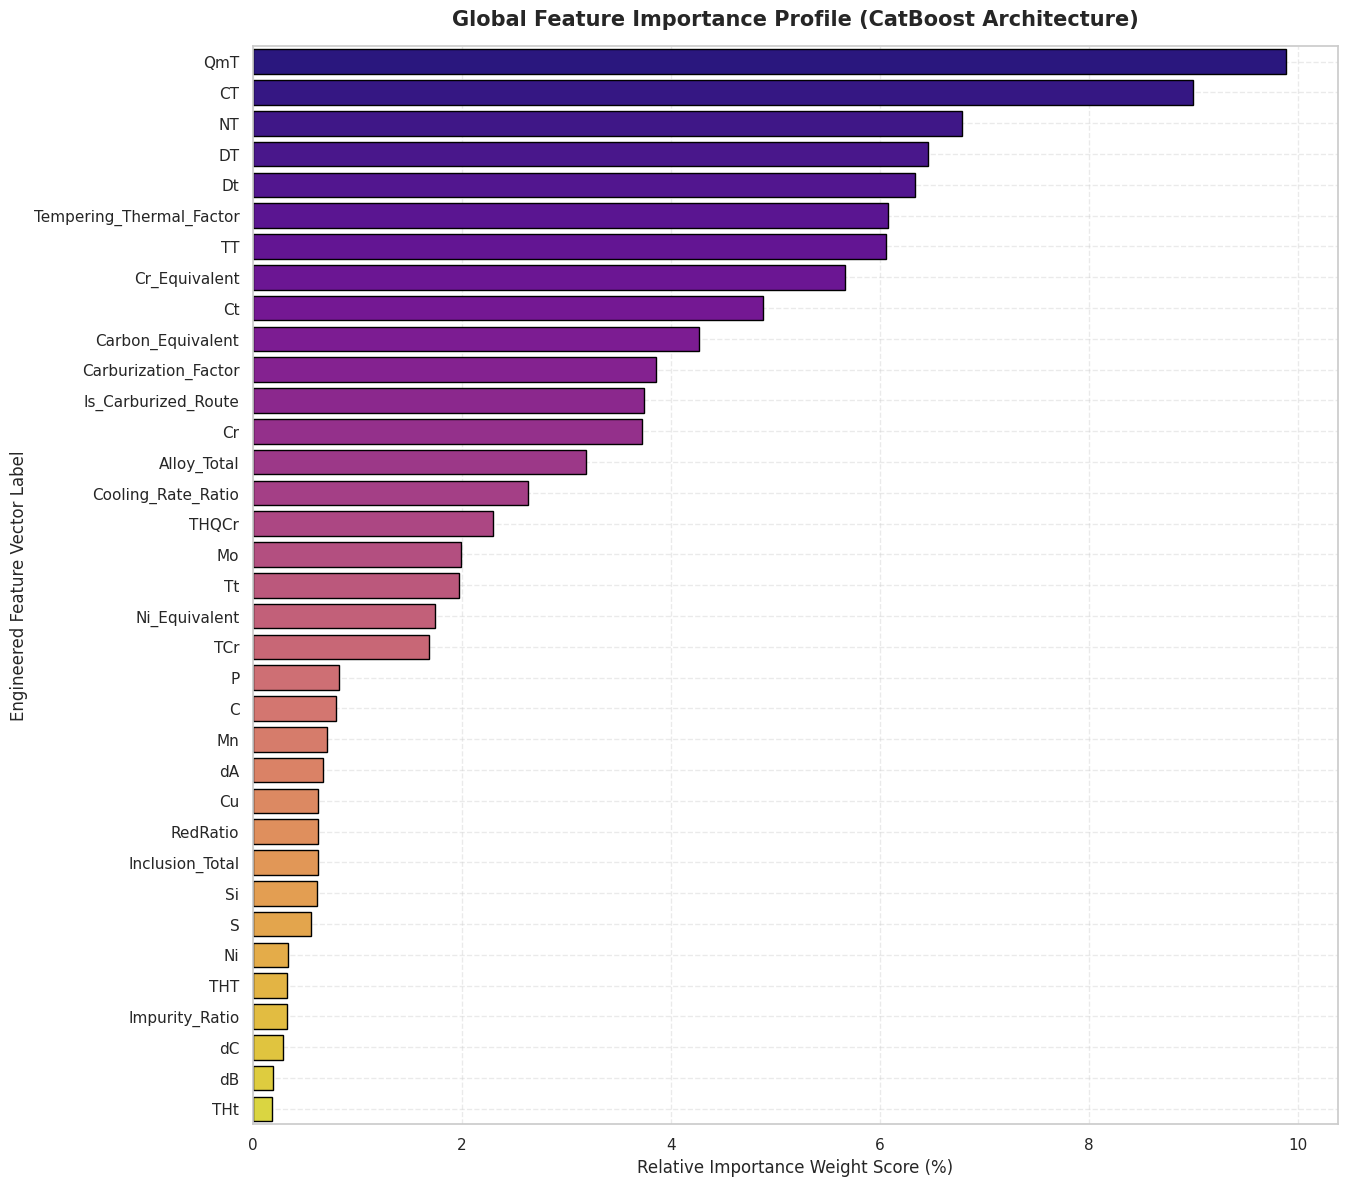

--- Leading Explanatory Feature Vectors Ranked ---


,Feature,Importance
8,QmT,9.882022
4,CT,8.991239
0,NT,6.786537
6,DT,6.455971
7,Dt,6.335706
30,Tempering_Thermal_Factor,6.081828
9,TT,6.056002
26,Cr_Equivalent,5.665530
5,Ct,4.882257
25,Carbon_Equivalent,4.272970


In [12]:
feature_importances = model_cat.get_feature_importance()
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(14, 14))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='plasma', edgecolor='black', linewidth=1.0)
plt.title('Global Feature Importance Profile (CatBoost Architecture)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Relative Importance Weight Score (%)', fontsize=12)
plt.ylabel('Engineered Feature Vector Label', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("--- Leading Explanatory Feature Vectors Ranked ---")
display(importance_df.head(10))

## Metallurgical Interpretations of Feature Importance

*   **Quenching Media Temperature (`QmT`) Dominance:** `QmT` ranks as the single most critical feature with an importance weight of 9.88202%. This matches heat-treatment physics: the temperature of the quenching medium determines the cooling rate across the material's cross-section. Managed quenching fluid temperatures (e.g., 60°C or 140°C) prevent high thermal shock and internal cracking while ensuring complete transformation into fine, uniform martensite or bainite.
*   **Carburization and Thermal Engineering Weights:** Carburizing temperature (`CT`, 8.99124%), Normalizing temperature (`NT`, 6.78654%), and Diffusion temperature (`DT`, 6.45597%) also rank prominently among the top explanatory features. This strong positioning underlines that the kinetics of surface carbon saturation and grain refinement are vital factors in determining fatigue life.
*   **Validation of Engineered Features:** The engineered feature `Tempering_Thermal_Factor` ranks 6th with an importance weight of 6.08183%, outperforming original standalone features like tempering time. This validates our domain-driven approach, proving that explicitly modeling the time-temperature interaction provides the tree models with a more effective representation of tempering transformation kinetics than raw, separated processing metrics.

# 10. Final Summary & Conclusions

- This research study establishes a highly accurate machine learning and deep learning framework for predicting steel fatigue strength using the National Institute for Materials Science (NIMS) experimental dataset. By engineering domain-specific features, such as the Carbon Equivalent, Schaeffler phase balance indices, and time-temperature kinetic factors, we successfully captured complex chemical and thermodynamic relationships within the data. 

- The competitive evaluation shows that non-linear ensemble models and deep neural networks achieve exceptional accuracy on this task, with the CatBoost Regressor leading performance at an $R^2$ score of 0.9820 and an RMSE of 25.3628 MPa. Feature importance analysis highlights that the quenching medium temperature (`QmT`) and carburizing parameters (`CT`) serve as the primary operational drivers of fatigue resistance, as they directly govern phase transformation kinetics and the formation of protective surface compressive residual stresses. Ultimately, this framework provides a robust, physics-informed tool for accelerating the computational design and lifetime verification of high-performance structural steels.